<a href="https://colab.research.google.com/github/hillarymaximino/metodos_numericos/blob/main/Atividade_05_M%C3%A9todos_N%C3%BAmericos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Implemente o algoritmo da iteração de ponto fixo usando somente a biblioteca Numpy.**

In [ ]:
import numpy as np

def ponto_fixo(g, x0, tol=0.001, max_iteracoes=100):
    x_atual = x0

    for i in range(max_iteracoes):
        x_novo = g(x_atual)
        erro = np.abs((x_novo - x_atual) / x_novo) * 100

        if erro <= tol:
            print(f"Sucesso! A Raiz encontrada: {x_novo:.5f} em {i+1} iterações.")
            return x_novo

        x_atual = x_novo

    print("Aviso: O método não convergiu dentro do limite de iterações.")
    return x_atual

**2. Use a iteração de ponto fixo simples para localizar a raiz de f (x) = 2 sin(px)− x, tendo x0 = 0, 5 e adotando como critério de parada o erro ea ≤ 0, 001%.**

In [ ]:
import numpy as np

def ponto_fixo(g, x0, tol=0.001, max_iteracoes=100):
    x_atual = x0

    for i in range(max_iteracoes):
        x_novo = g(x_atual)
        erro = np.abs((x_novo - x_atual) / x_novo) * 100

        if erro <= tol:
            print(f"Sucesso! A Raiz encontrada: {x_novo:.5f} em {i+1} iterações.")
            return x_novo

        x_atual = x_novo

    print("Aviso: O método não convergiu dentro do limite de iterações.")
    return x_atual



def g(x):
    return 2 * np.sin(np.sqrt(x))

x0 = 0.5
tol = 0.001

print("Iniciando o Método da Iteração de Ponto Fixo...\n")
raiz = ponto_fixo(g, x0, tol)

Iniciando o Método da Iteração de Ponto Fixo...

Sucesso! A Raiz encontrada: 1.97238 em 8 iterações.


**3. Determine a maior raiz real de f (x) = 2x^3 − 11.7x^2 + 17.7x − 5**

*(a) Graficamente;*

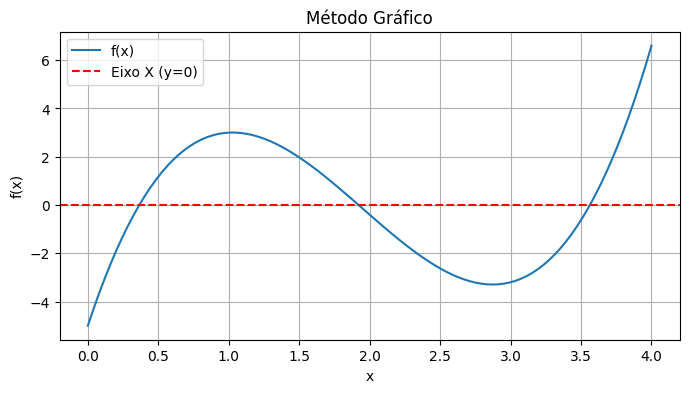

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return 2*x**3 - 11.7*x**2 + 17.7*x - 5

x_vals = np.linspace(0, 4, 100)
y_vals = f(x_vals)

plt.figure(figsize=(8, 4))
plt.plot(x_vals, y_vals, label='f(x)')
plt.axhline(0, color='red', linestyle='--', label='Eixo X (y=0)')
plt.grid(True)
plt.title("Método Gráfico")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.show()

*(b) Pelo método da Bisseção (5 iterações, escolha o intervalo pela visualização gráfica)*

In [ ]:
a = 3.0
b = 4.0
iteracoes = 5

for i in range(1, iteracoes + 1):
    xm = (a + b) / 2
    f_a = f(a)
    f_xm = f(xm)

    print(f"Iteração {i}: a={a:.4f}, b={b:.4f}, xm={xm:.4f}, f(xm)={f_xm:.4f}")

    if f_a * f_xm < 0:
        b = xm
    else:
        a = xm

Iteração 1: a=3.0000, b=4.0000, xm=3.5000, f(xm)=-0.6250
Iteração 2: a=3.5000, b=4.0000, xm=3.7500, f(xm)=2.3125
Iteração 3: a=3.5000, b=3.7500, xm=3.6250, f(xm)=0.6867
Iteração 4: a=3.5000, b=3.6250, xm=3.5625, f(xm)=-0.0069
Iteração 5: a=3.5625, b=3.6250, xm=3.5938, f(xm)=0.3303


*(c) Pelo método da iteração de ponto fixo (5 iterações, x0 = 3 – certifique-se de desenvolver
uma solução que convirja para a raiz);*

In [ ]:
def g(x):
    return (-2*x**3 + 11.7*x**2 + 5) / 17.7

x_atual = 3.0
iteracoes = 5

print(f"Iteração 0: x = {x_atual:.5f}")

for i in range(1, iteracoes + 1):
    x_novo = g(x_atual)
    print(f"Iteração {i}: x = {x_novo:.5f}")
    x_atual = x_novo

Iteração 0: x = 3.00000
Iteração 1: x = 3.18079
Iteração 2: x = 3.33396
Iteração 3: x = 3.44254
Iteração 4: x = 3.50633
Iteração 5: x = 3.53829


**4. Compare os métodos da bisseção, falsa posição e do ponto fixo localizando a raiz x ∗ das seguintes equações:**

In [ ]:
import time
import math

def bissecao(f, a, b, tol, max_iter):
    if f(a) * f(b) >= 0:
        return None, 0, True, 0.0
    start_time = time.perf_counter()
    for i in range(max_iter):
        c = (a + b) / 2
        if abs(f(c)) < tol or (b - a) / 2 < tol:
            return c, i + 1, False, time.perf_counter() - start_time
        if f(a) * f(c) < 0:
            b = c
        else:
            a = c
    return (a + b) / 2, max_iter, True, time.perf_counter() - start_time

def falsa_posicao(f, a, b, tol, max_iter):
    if f(a) * f(b) >= 0:
        return None, 0, True, 0.0
    start_time = time.perf_counter()
    c = a
    for i in range(max_iter):
        c_velho = c
        fa_val = f(a)
        fb_val = f(b)
        if fb_val - fa_val == 0:
            return c, i + 1, True, time.perf_counter() - start_time
        c = (a * fb_val - b * fa_val) / (fb_val - fa_val)
        if abs(f(c)) < tol or abs(c - c_velho) < tol:
            return c, i + 1, False, time.perf_counter() - start_time
        if fa_val * f(c) < 0:
            b = c
        else:
            a = c
    return c, max_iter, True, time.perf_counter() - start_time

def ponto_fixo(g, x0, tol, max_iter):
    start_time = time.perf_counter()
    x = x0
    for i in range(max_iter):
        try:
            x_novo = g(x)
            if abs(x_novo - x) < tol:
                return x_novo, i + 1, False, time.perf_counter() - start_time
            x = x_novo
        except (OverflowError, ValueError, ZeroDivisionError):
            return x, i + 1, True, time.perf_counter() - start_time
    return x, max_iter, True, time.perf_counter() - start_time

equacoes = [
    (
        "a",
        lambda x: 2*x**4 + 4*x**3 + 3*x**2 - 10*x - 15,
        lambda x: (2*x**4 + 4*x**3 + 3*x**2 - 15) / 10,
        0, 3
    ),
    (
        "b",
        lambda x: (x + 3)*(x + 1)*(x - 2)**3,
        lambda x: x - ((x + 3)*(x + 1)*(x - 2)**3)/100,
        0, 5
    ),
    (
        "c",
        lambda x: 5*x**3 + x**2 - math.exp(1 - 2*x) + math.cos(x) + 20,
        lambda x: x - (5*x**3 + x**2 - math.exp(1 - 2*x) + math.cos(x) + 20)/100,
        -5, 5
    ),
    (
        "d",
        lambda x: math.sin(x)*x + 4,
        lambda x: x - (math.sin(x)*x + 4)/10,
        1, 5
    ),
    (
        "e",
        lambda x: ((x - 3)**5) * math.log(x) if x > 0 else float('inf'),
        lambda x: x - (((x - 3)**5) * math.log(x))/100 if x > 0 else float('inf'),
        2, 5
    ),
    (
        "f",
        lambda x: x**10 - 1,
        lambda x: x - (x**10 - 1)/10,
        0.8, 1.2
    )
]

tol = 1e-10
max_iter = 200

for nome, f, g, a, b in equacoes:
    print(f"Equação ({nome})")

    raiz_b, iter_b, erro_b, tempo_b = bissecao(f, a, b, tol, max_iter)
    str_raiz_b = f"{raiz_b:.10f}" if raiz_b is not None else "N/A"
    print(f"Bisseção      | Raiz: {str_raiz_b:<15} | Iter: {iter_b:<3} | Erro: {str(erro_b):<5} | Tempo: {tempo_b:.6f}s")

    raiz_fp, iter_fp, erro_fp, tempo_fp = falsa_posicao(f, a, b, tol, max_iter)
    str_raiz_fp = f"{raiz_fp:.10f}" if raiz_fp is not None else "N/A"
    print(f"Falsa Posição | Raiz: {str_raiz_fp:<15} | Iter: {iter_fp:<3} | Erro: {str(erro_fp):<5} | Tempo: {tempo_fp:.6f}s")

    raiz_pf, iter_pf, erro_pf, tempo_pf = ponto_fixo(g, b, tol, max_iter)
    str_raiz_pf = f"{raiz_pf:.10f}" if isinstance(raiz_pf, (int, float)) and not math.isnan(raiz_pf) and not math.isinf(raiz_pf) else "N/A"
    print(f"Ponto Fixo    | Raiz: {str_raiz_pf:<15} | Iter: {iter_pf:<3} | Erro: {str(erro_pf):<5} | Tempo: {tempo_pf:.6f}s\n")

Equação (a)
Bisseção      | Raiz: 1.4928787086    | Iter: 35  | Erro: False | Tempo: 0.000062s
Falsa Posição | Raiz: 1.4928787085    | Iter: 65  | Erro: False | Tempo: 0.000097s
Ponto Fixo    | Raiz: 4225470153913846748567501374704150158409469653960338867633267176187291001421824.0000000000 | Iter: 5   | Erro: True  | Tempo: 0.000014s

Equação (b)
Bisseção      | Raiz: 2.0001220703    | Iter: 13  | Erro: False | Tempo: 0.000012s
Falsa Posição | Raiz: 1.7144091362    | Iter: 200 | Erro: True  | Tempo: 0.000174s
Ponto Fixo    | Raiz: -18215920229620333237474244090893735693805685469386671616822889967029820237003530379069670563177169564427275567482979810279602069756040240494503304122509034341630500461073014823328759875596729865796805788498490001433308634129940658238831851632111673933824.0000000000 | Iter: 6   | Erro: True  | Tempo: 0.000005s

Equação (c)
Bisseção      | Raiz: -0.9295604598   | Iter: 37  | Erro: False | Tempo: 0.000048s
Falsa Posição | Raiz: 1.5687692611    | Iter: 200 | Err